In [1]:
import os
import pandas as pd
from Bio import SeqIO

# 1. 确保在仓库根目录
path = os.getcwd()
while path != os.path.dirname(path):  # 只要还没退到系统最顶层
    if "week1_environment_check" in os.listdir(path):
        os.chdir(path)
        break
    path = os.path.dirname(path)

print("当前工作目录已在仓库根目录:", os.getcwd())

# 2. 定义输入和输出的相对路径
fasta_path = "week1_environment_check/data/demo_sequences.fasta"
output_path = "submissions/paddypasteur/week1/results/week1_sequence_stats.csv"

# 3. 计算 4 个参数：sequence_id, length, GC_count, GC_percent
records_data = []

for record in SeqIO.parse(fasta_path, "fasta"):
    seq = record.seq
    length = len(seq)
    
    # 统计 G 和 C 的数量，SeqIO 读出来默认是大写，转 uppercase 以防万一
    gc_count = seq.upper().count('G') + seq.upper().count('C')
    
    # 计算 GC 占比,四舍五入，保留一位小数
    gc_percent = round((gc_count / length) * 100, 1) if length > 0 else 0.0
    
    # 改名
    records_data.append({
        "sequence_id": record.id,
        "length": length,
        "GC_count": gc_count,
        "GC_percent": gc_percent
    })

# 4. 将结果转为 DataFrame 表格
df = pd.DataFrame(records_data)

# 5. 输出 CSV 表格
df.to_csv(output_path, index=False)
print("任务 1 已完成！结果已保存至:", output_path)

当前工作目录已在仓库根目录: /mnt/e/Linux/bioinformatics/igem/igem-model-training-2027
任务 1 已完成！结果已保存至: submissions/paddypasteur/week1/results/week1_sequence_stats.csv


In [2]:
# 1. 定义测量数据 CSV 文件的路径
csv_path = "week1_environment_check/data/demo_measurements.csv"

# 2. 用 pandas 读取文件，并存成一个名为 df_meas 的表格对象
df_meas = pd.read_csv(csv_path)

# 3. 按照公式，新增一列，列名为 normalized_fluorescence，是fluorescence除以od600
df_meas['normalized_fluorescence'] = df_meas['fluorescence'] / df_meas['od600']

# 4. 预览前五行
df_meas.head()

,sample_id,group,sequence_id,fluorescence,od600,normalized_fluorescence
0,S01,control,seq_001_promoter_like,1200,0.82,1463.414634
1,S02,control,seq_002_AT_rich,980,0.79,1240.506329
2,S03,control,seq_003_GC_rich,1500,0.85,1764.705882
3,S04,treatment,seq_001_promoter_like,2100,0.81,2592.592593
4,S05,treatment,seq_002_AT_rich,1300,0.80,1625.000000


In [3]:
# 1. 定义输出文件路径
merged_output_path = "submissions/paddypasteur/week1/results/week1_merged_table.csv"

# 2. 按照序列id将 测量表 df_meas 和 序列统计表 df 进行合并
# how='inner' 求交集
df_merged = pd.merge(df_meas, df, on="sequence_id", how="inner")

# 将新表格写入到文件中（不保存最左边的索引行 index）
df_merged.to_csv(merged_output_path, index=False)

print("任务 3 已完成！合并后的表格已写入硬盘:", merged_output_path)

# 4. 预览前五行
df_merged.head()

任务 3 已完成！合并后的表格已写入硬盘: submissions/paddypasteur/week1/results/week1_merged_table.csv


,sample_id,group,sequence_id,fluorescence,od600,normalized_fluorescence,length,GC_count,GC_percent
0,S01,control,seq_001_promoter_like,1200,0.82,1463.414634,14,7,50.0
1,S02,control,seq_002_AT_rich,980,0.79,1240.506329,10,0,0.0
2,S03,control,seq_003_GC_rich,1500,0.85,1764.705882,8,8,100.0
3,S04,treatment,seq_001_promoter_like,2100,0.81,2592.592593,14,7,50.0
4,S05,treatment,seq_002_AT_rich,1300,0.80,1625.000000,10,0,0.0


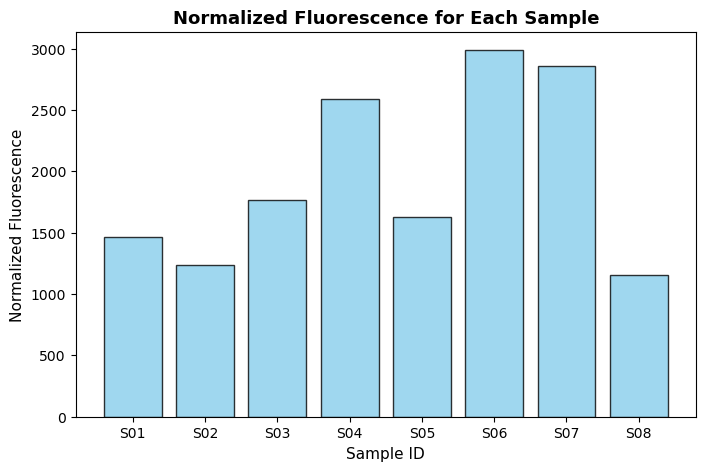

In [4]:
import matplotlib.pyplot as plt

# 1. 创建一张空白画布（宽 8 英寸，高 5 英寸）
plt.figure(figsize=(8, 5))

# 2. 绘制柱状图
# x 轴是 sample_id，y 轴是刚算出来的 normalized_fluorescence
# 颜色设为天蓝色，加上黑色边框，稍微带一点透明度
plt.bar(df_merged['sample_id'], df_merged['normalized_fluorescence'], 
        color='skyblue', edgecolor='black', alpha=0.8)

# 3. 添加坐标轴标签和标题，调整字体大小和粗细
plt.xlabel('Sample ID', fontsize=11)
plt.ylabel('Normalized Fluorescence', fontsize=11)
plt.title('Normalized Fluorescence for Each Sample', fontsize=13, fontweight='bold')

# 4. 保存
plot1_path = "submissions/paddypasteur/week1/figures/week1_normalized_fluorescence_bar.png"

# 高分辨率输出
# 自动紧凑排版，防止边缘的标签在保存时被切掉
plt.savefig(plot1_path, dpi=300, bbox_inches='tight')

# 5. 预览
plt.show()

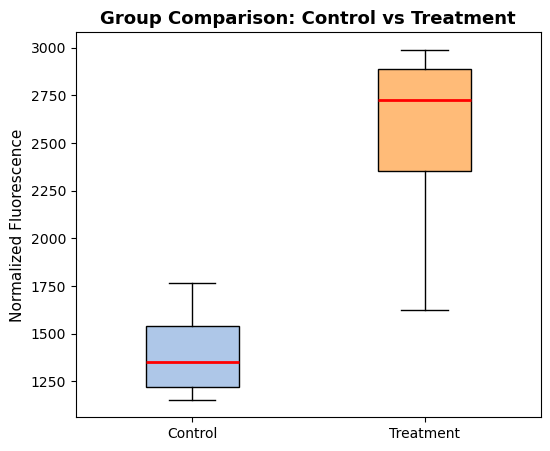

In [5]:
# 1. 提取两组各自的标准化荧光数据
# 逻辑：从 df_merged 表格里，筛选出 group 列为 'control' 的行，并取出它们的 normalized_fluorescence 值
control_data = df_merged[df_merged['group'] == 'control']['normalized_fluorescence']
treatment_data = df_merged[df_merged['group'] == 'treatment']['normalized_fluorescence']

# 2. 创建画布
plt.figure(figsize=(6, 5))

# 3. 绘制箱线图，控制箱子的宽度
box = plt.boxplot([control_data, treatment_data], 
                  tick_labels=['Control', 'Treatment'], 
                  patch_artist=True, 
                  widths=0.4)

# 4. 涂色
# 我选了一组非常柔和高级的淡蓝和淡橘色
colors = ['#aec7e8', '#ffbb78'] 
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')  # 黑色描边

# 5. 把中位数设为醒目的红色并加粗，方便观察
for median in box['medians']:
    median.set_color('red')
    median.set_linewidth(2)

# 6. 添加标签和标题
plt.ylabel('Normalized Fluorescence', fontsize=11)
plt.title('Group Comparison: Control vs Treatment', fontsize=13, fontweight='bold')

# 7. 保存
plot2_path = "submissions/paddypasteur/week1/figures/week1_group_comparison.png"
plt.savefig(plot2_path, dpi=300, bbox_inches='tight')

# 8. 预览
plt.show()

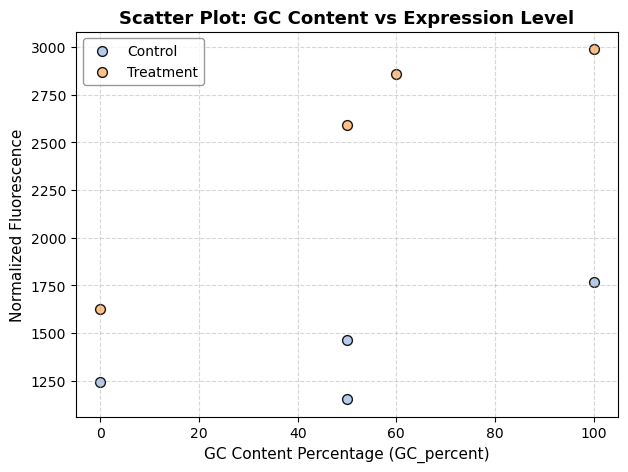

In [6]:
# 1. 区分两组的数据，以便用不同的颜色和标签绘制
control_mask = df_merged['group'] == 'control'
treatment_mask = df_merged['group'] == 'treatment'

# 2. 创建画布
plt.figure(figsize=(7, 5))

# 3. 绘制 Control 组的散点（淡蓝色，圆点 s=100 控制点的大小，edgecolor 加上黑色描边）
plt.scatter(df_merged[control_mask]['GC_percent'], 
            df_merged[control_mask]['normalized_fluorescence'], 
            color='#aec7e8', label='Control', s=50, edgecolor='black', alpha=0.9)

# 4. 绘制 Treatment 组的散点（淡橘色，圆点）
plt.scatter(df_merged[treatment_mask]['GC_percent'], 
            df_merged[treatment_mask]['normalized_fluorescence'], 
            color='#ffbb78', label='Treatment', s=50, edgecolor='black', alpha=0.9)

# 5. 添加轻量背景网格线，方便看着对齐读数
plt.grid(True, linestyle='--', alpha=0.5)

# 6. 添加坐标轴标签、标题和图例
plt.xlabel('GC Content Percentage (GC_percent)', fontsize=11)
plt.ylabel('Normalized Fluorescence', fontsize=11)
plt.title('Scatter Plot: GC Content vs Expression Level', fontsize=13, fontweight='bold')

# 显示图例
plt.legend(frameon=True, facecolor='white', edgecolor='gray')

# 7. 保存
plot3_path = "submissions/paddypasteur/week1/figures/week1_gc_vs_expression.png"
plt.savefig(plot3_path, dpi=300, bbox_inches='tight')

# 8. 在 Jupyter 页面中显示
plt.show()